In [1]:
import pandas as pd
import numpy as np
#Plotting
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap

In [2]:
### Read in the Arene/Aryne SMILES.csv dataset ###
csv_name = '5_membered_Calculated_Molecular_Descriptors'
five_data = pd.read_csv(f'{csv_name}.csv')
print(len(five_data))
five_data.head()

1469


,arene_id,arene_smiles,arene_energy,aryne_id,aryne_smiles,aryne_energy,dehydrogenation_energy,Sz_Aryne_Ring,RingSys_Type,Aryne_Aindx_1,...,Sum_abs_dev,Aryne_DiH_Ang,eHOMO(eV),eLUMO(eV),H_L_Gap(eV),Hirsh_chgs_Aindx_1,Hirsh_chgs_Aindx_2,Sum_Abs_Hirsh_aryne,Abs_Dif_Bnd_Angl,Modulo_Bnd_Angl
0,arene_1,O=c1nc2ccsc2cs1,-1156.0883,aryne_1,O=c1nc2c#csc2cs1,-1154.7269,124.0423,5,multi,4,...,20.9698,0.091,-8.2033,-3.1162,5.0871,0.0001,-0.0688,0.0689,13.8672,13.8672
1,arene_16,c1c[nH]nn1,-241.9423,aryne_17,c1nn[nH]c#1,-240.5255,158.8063,5,mono,4,...,40.2947,0.046,-9.2856,-3.3609,5.9247,-0.1557,0.1634,0.3191,40.2947,40.2947
2,arene_30,O=c1ccn2c(=O)[nH]ccn12,-545.7148,aryne_33,O=c1[nH]ccn2c(=O)c#cn12,-544.3235,142.8048,5,multi,8,...,9.6764,6.498,-7.5361,-3.2572,4.2789,-0.0603,0.0185,0.0788,3.9664,3.9664
3,arene_38,O=c1cnc2nccn2o1,-506.3813,aryne_42,O=c1cnc2nc#cn2o1,-504.9847,146.1306,5,multi,6,...,42.2232,0.057,-8.8042,-3.3330,5.4712,0.1627,-0.1413,0.3040,42.2232,42.2232
4,arene_42,O=c1ccc2occc2o1,-494.2334,aryne_47,O=c1ccc2oc#cc2o1,-492.8235,154.4765,5,multi,6,...,32.8263,0.052,-8.0099,-3.5878,4.4221,0.1295,-0.1182,0.2477,32.8263,32.8263


In [3]:
### Read in the Arene/Aryne SMILES.csv dataset ###
csv_name = '6_membered_Calculated_Molecular_Descriptors'
six_data = pd.read_csv(f'{csv_name}.csv')
print(len(six_data))
six_data.head()

6641


,arene_id,arene_smiles,arene_energy,aryne_id,aryne_smiles,aryne_energy,dehydrogenation_energy,Sz_Aryne_Ring,RingSys_Type,Aryne_Aindx_1,...,Sum_abs_dev,Aryne_DiH_Ang,eHOMO(eV),eLUMO(eV),H_L_Gap(eV),Hirsh_chgs_Aindx_1,Hirsh_chgs_Aindx_2,Sum_Abs_Hirsh_aryne,Abs_Dif_Bnd_Angl,Modulo_Bnd_Angl
0,arene_2,c1csn2nn[nH]cc-2o1,-846.4294,aryne_2,c1oc2c[nH]nnn-2sc#1,-845.1003,103.7738,6,multi,9,...,32.3229,9.361,-7.5885,-1.8409,5.7476,-0.1534,0.0712,0.2246,32.3229,32.3229
1,arene_3,O=c1cnc2occsc=2c1=O,-946.3140,aryne_3,O=c1cnc2oc#csc=2c1=O,-944.9744,110.3626,6,multi,6,...,28.5260,0.049,-7.6077,-3.6957,3.9120,0.0756,-0.1217,0.1973,27.4140,27.4140
2,arene_4,O=c1cnc2sc(=O)ccc2s1,-1269.2819,aryne_4,O=c1c#cc2sc(=O)cnc2s1,-1267.9693,93.4199,6,multi,2,...,29.2699,0.582,-8.2904,-2.7467,5.5437,-0.0285,-0.0286,0.0571,2.8089,2.8089
3,arene_5,O=c1ccn2sccsn2[nH]1,-1228.5052,aryne_5,O=c1c#cn2sccsn2[nH]1,-1227.1702,107.4761,6,multi,2,...,15.8775,28.895,-7.5024,-1.8204,5.6820,-0.1116,0.0126,0.1242,15.8775,15.8775
4,arene_7,O=c1ncn2cnccn2c1=O,-599.7472,aryne_8,O=c1ncn2cnc#cn2c1=O,-598.3859,123.9795,6,multi,7,...,28.4099,0.193,-7.9336,-2.5449,5.3887,0.0734,-0.0427,0.1161,28.4099,28.4099


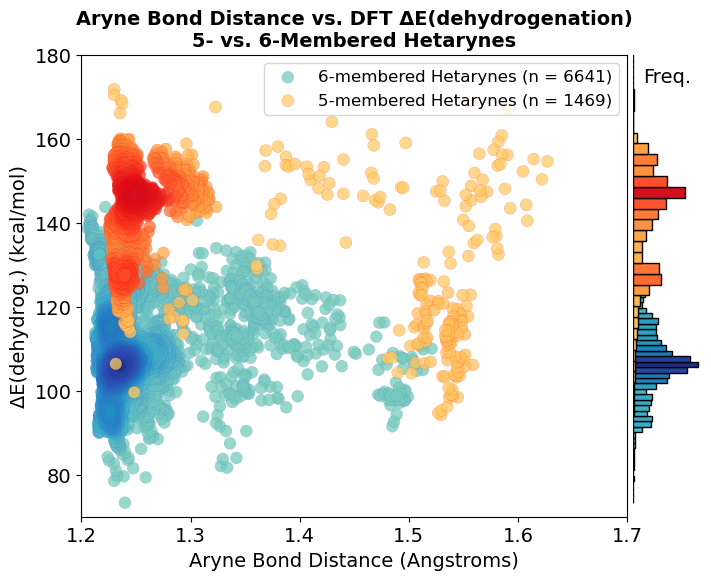

In [8]:
### Plot Maximum Internal Bond Angle vs. Dehydration Energies ###
### 6-membered Rings ### 
x1_angles = six_data['Aryne_Bond_Dist(A)']
y1_energies = six_data['dehydrogenation_energy']
xy1 = np.stack([x1_angles, y1_energies])
xy1_density = gaussian_kde(xy1)(xy1)
idx1 = xy1_density.argsort()
x1_angles, y1_energies, xy1_density = x1_angles[idx1], y1_energies[idx1], xy1_density[idx1]
#6mem_colormap
my_blu = plt.cm.YlGnBu(np.linspace(0.35,0.9,100))
my_blu = ListedColormap(my_blu[8:,:-1])

### 5-membered Rings ###
x_angles = five_data['Aryne_Bond_Dist(A)']
y_energies = five_data['dehydrogenation_energy']
xy = np.stack([x_angles, y_energies])
xy_density = gaussian_kde(xy)(xy)
idx = xy_density.argsort()
x_angles, y_energies, xy_density = x_angles[idx], y_energies[idx], xy_density[idx]
#5-membered colormap
my_yrs = plt.cm.YlOrRd(np.linspace(0.25,0.8,100))
my_yrs = ListedColormap(my_yrs[8:,:-1])

##setting up the fig with subplots###
fig = plt.figure(figsize=(8, 6))
#set the relative spacing of the two subplots
gs = fig.add_gridspec(1, 2, width_ratios=(8, 1))
plt.subplots_adjust(wspace=0.02)

#initialize the subplots in their relative positions
ax_scatter = fig.add_subplot(gs[0, 0])
ax_hist_y = fig.add_subplot(gs[0, 1])

#plot the scatter data
#6-membered scatter data
ax_scatter.scatter(x1_angles, y1_energies, c=xy1_density, cmap=my_blu, linewidths=0.1,
                   edgecolors='royalblue', alpha=0.75, s=75, label='6-membered Hetarynes (n = 6641)')
                  
#5-membered scatter data
ax_scatter.scatter(x_angles, y_energies, c=xy_density, cmap=my_yrs, linewidths=0.1,
                   edgecolors='red', alpha=0.75, s=75, label='5-membered Hetarynes (n = 1469)')
                  

#Plot Parameters for the left-side Scatterplot
ax_scatter.set_xlim(1.2,1.7)
ax_scatter.set_ylim(70,180)
ax_scatter.set_title("Aryne Bond Distance vs. DFT ΔE(dehydrogenation)\n5- vs. 6-Membered Hetarynes",
                     fontsize=14, fontweight='bold'
                    )
ax_scatter.set_xlabel("Aryne Bond Distance (Angstroms)", fontsize=14)
ax_scatter.set_ylabel("ΔE(dehydrog.) (kcal/mol)", fontsize=14)
ax_scatter.tick_params(axis='both', which='major', labelsize=14)
ax_scatter.tick_params(axis="y", labelleft=True)
ax_scatter.legend(loc='upper right', fontsize=12)

#plot Histo data - first is for 6 membered
m, bins, patches = ax_hist_y.hist(y1_energies, bins=100, density=True, edgecolor='black',
                                  label='6-membered Hetarynes', orientation='horizontal'
                                 )
bol = (m-m.min())/(m.max()-m.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_blu(c))

#plot Histo data - next is for 5 mem
n, bins, patches = ax_hist_y.hist(y_energies, bins=30, density=True, edgecolor='black',
                                  label='6-membered Hetarynes', orientation='horizontal'
                                 )
bol = (n-n.min())/(n.max()-n.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_yrs(c))

#set the y limit to match the scatter
ax_hist_y.set_ylim(70,180)

#Plot Parameters for the right-side Histogram
ax_hist_y.xaxis.set_label_position('top')
ax_hist_y.set_xlabel("Freq.", fontsize=14, labelpad=-20, loc='center')
ax_hist_y.set_yticks([])
ax_hist_y.set_xticks([])
#remove the lines around the histo plot
ax_hist_y.spines['top'].set_visible(False)
ax_hist_y.spines['bottom'].set_visible(False)
ax_hist_y.spines['right'].set_visible(False)
ax_hist_y.spines['left'].set_visible(False)

#output a copy of the plot to local drive
plt.savefig('5_vs_6_Aryne_Bond_Distance_vs_dEdehyd_with_histos.png', bbox_inches="tight",
            transparent=True, dpi=600
           )
plt.show()

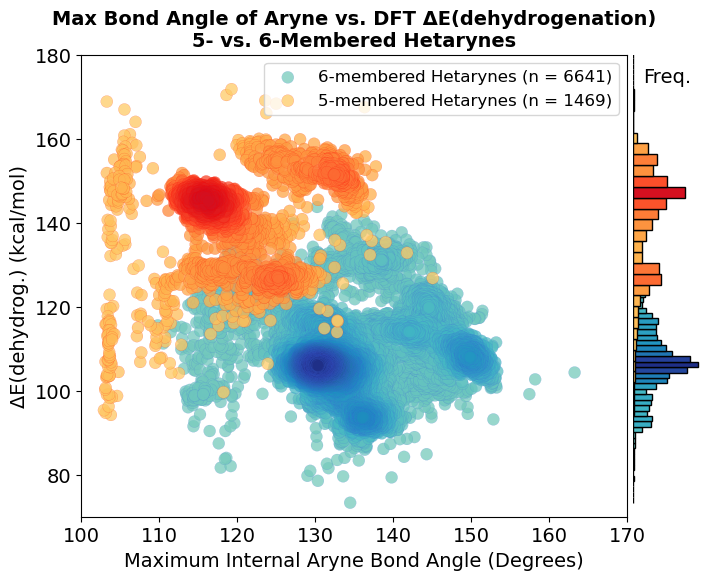

In [9]:
### Plot Maximum Internal Bond Angle vs. Dehydration Energies ###
### 6-membered Rings ### 
x1_angles = six_data['Max_Aryne_BndAngl']
y1_energies = six_data['dehydrogenation_energy']
xy1 = np.stack([x1_angles, y1_energies])
xy1_density = gaussian_kde(xy1)(xy1)
idx1 = xy1_density.argsort()
x1_angles, y1_energies, xy1_density = x1_angles[idx1], y1_energies[idx1], xy1_density[idx1]
#6mem_colormap
my_blu = plt.cm.YlGnBu(np.linspace(0.35,0.9,100))
my_blu = ListedColormap(my_blu[8:,:-1])

### 5-membered Rings ###
x_angles = five_data['Max_Aryne_BndAngl']
y_energies = five_data['dehydrogenation_energy']
xy = np.stack([x_angles, y_energies])
xy_density = gaussian_kde(xy)(xy)
idx = xy_density.argsort()
x_angles, y_energies, xy_density = x_angles[idx], y_energies[idx], xy_density[idx]
#5-membered colormap
my_yrs = plt.cm.YlOrRd(np.linspace(0.25,0.8,100))
my_yrs = ListedColormap(my_yrs[8:,:-1])

##setting up the fig with subplots###
fig = plt.figure(figsize=(8, 6))
#set the relative spacing of the two subplots
gs = fig.add_gridspec(1, 2, width_ratios=(8, 1))
plt.subplots_adjust(wspace=0.02)

#initialize the subplots in their relative positions
ax_scatter = fig.add_subplot(gs[0, 0])
ax_hist_y = fig.add_subplot(gs[0, 1])

#plot the scatter data
#6-membered scatter data
ax_scatter.scatter(x1_angles, y1_energies, c=xy1_density, cmap=my_blu, linewidths=0.1,
                   edgecolors='royalblue', alpha=0.75, s=75, label='6-membered Hetarynes (n = 6641)')
                  
#5-membered scatter data
ax_scatter.scatter(x_angles, y_energies, c=xy_density, cmap=my_yrs, linewidths=0.1,
                   edgecolors='red', alpha=0.75, s=75, label='5-membered Hetarynes (n = 1469)')
                   
#Plot Parameters for the left-side Scatterplot
ax_scatter.set_xlim(100,170)
ax_scatter.set_ylim(70,180)
ax_scatter.set_title("Max Bond Angle of Aryne vs. DFT ΔE(dehydrogenation)\n5- vs. 6-Membered Hetarynes",
                     fontsize=14, fontweight='bold'
                    )
ax_scatter.set_xlabel("Maximum Internal Aryne Bond Angle (Degrees)", fontsize=14)
ax_scatter.set_ylabel("ΔE(dehydrog.) (kcal/mol)", fontsize=14)
ax_scatter.tick_params(axis='both', which='major', labelsize=14)
ax_scatter.tick_params(axis="y", labelleft=True)
ax_scatter.legend(loc='upper right', fontsize=12)


#plot Histo data - first is for 6 membered
m, bins, patches = ax_hist_y.hist(y1_energies, bins=100, density=True, edgecolor='black',
                                  label='6-membered Hetarynes', orientation='horizontal'
                                 )
bol = (m-m.min())/(m.max()-m.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_blu(c))

#plot Histo data - next is for 5 mem
n, bins, patches = ax_hist_y.hist(y_energies, bins=30, density=True, edgecolor='black',
                                  label='6-membered Hetarynes', orientation='horizontal'
                                 )
bol = (n-n.min())/(n.max()-n.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_yrs(c))

#set the y limit to match the scatter
ax_hist_y.set_ylim(70,180)

#Plot Parameters for the right-side Histogram
ax_hist_y.xaxis.set_label_position('top')
ax_hist_y.set_xlabel("Freq.", fontsize=14, labelpad=-20, loc='center')
ax_hist_y.set_yticks([])
ax_hist_y.set_xticks([])
#remove the lines around the histo plot
ax_hist_y.spines['top'].set_visible(False)
ax_hist_y.spines['bottom'].set_visible(False)
ax_hist_y.spines['right'].set_visible(False)
ax_hist_y.spines['left'].set_visible(False)

#output a copy of the plot to local drive
plt.savefig('5_vs_6_Max_Bond_Angle_vs_dEdehyd_with_histos.png', bbox_inches="tight",
            transparent=True, dpi=600
           )
plt.show()

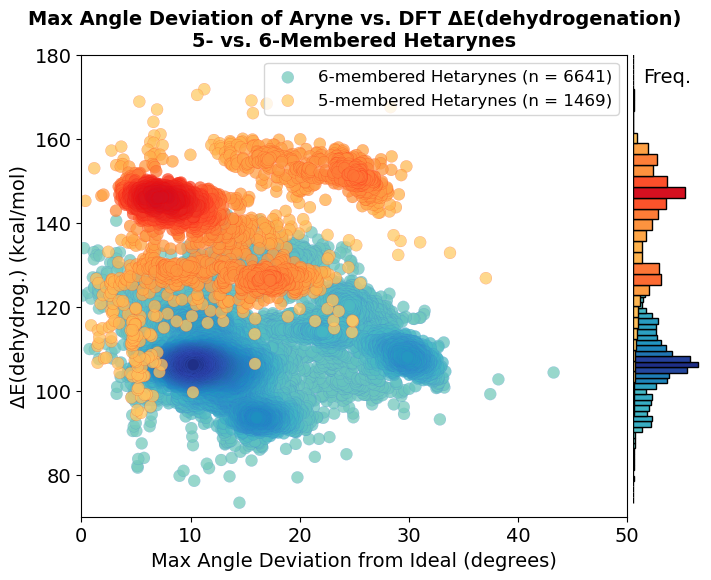

In [10]:
### Plot Aryne Maximum Angle Deviation vs. Dehydration Energies ###
### 6-membered Rings ### 
x1_angles = six_data['Max_angle_dev']
y1_energies = six_data['dehydrogenation_energy']
xy1 = np.stack([x1_angles, y1_energies])
xy1_density = gaussian_kde(xy1)(xy1)
idx1 = xy1_density.argsort()
x1_angles, y1_energies, xy1_density = x1_angles[idx1], y1_energies[idx1], xy1_density[idx1]
#6mem_colormap
my_blu = plt.cm.YlGnBu(np.linspace(0.35,0.9,100))
my_blu = ListedColormap(my_blu[8:,:-1])

### 5-membered Rings ###
x_angles = five_data['Max_angle_dev']
y_energies = five_data['dehydrogenation_energy']
xy = np.stack([x_angles, y_energies])
xy_density = gaussian_kde(xy)(xy)
idx = xy_density.argsort()
x_angles, y_energies, xy_density = x_angles[idx], y_energies[idx], xy_density[idx]
#5-membered colormap
my_yrs = plt.cm.YlOrRd(np.linspace(0.25,0.8,100))
my_yrs = ListedColormap(my_yrs[8:,:-1])

##setting up the fig with subplots###
fig = plt.figure(figsize=(8, 6))
#set the relative spacing of the two subplots
gs = fig.add_gridspec(1, 2, width_ratios=(8, 1))
plt.subplots_adjust(wspace=0.02)

#initialize the subplots in their relative positions
ax_scatter = fig.add_subplot(gs[0, 0])
ax_hist_y = fig.add_subplot(gs[0, 1])

#plot the scatter data
#6-membered scatter data
ax_scatter.scatter(x1_angles, y1_energies, c=xy1_density, cmap=my_blu, linewidths=0.1,
                   edgecolors='royalblue', alpha=0.75, s=75, label='6-membered Hetarynes (n = 6641)')
                  
#5-membered scatter data
ax_scatter.scatter(x_angles, y_energies, c=xy_density, cmap=my_yrs, linewidths=0.1,
                   edgecolors='red', alpha=0.75, s=75, label='5-membered Hetarynes (n = 1469)')

#Plot Parameters for the left-side Scatterplot
ax_scatter.set_xlim(0,50)
ax_scatter.set_ylim(70,180)
ax_scatter.set_title("Max Angle Deviation of Aryne vs. DFT ΔE(dehydrogenation)\n5- vs. 6-Membered Hetarynes",
                     fontsize=14, fontweight='bold'
                    )
ax_scatter.set_xlabel("Max Angle Deviation from Ideal (degrees)", fontsize=14)
ax_scatter.set_ylabel("ΔE(dehydrog.) (kcal/mol)", fontsize=14)
ax_scatter.tick_params(axis='both', which='major', labelsize=14)
ax_scatter.legend(loc='upper right', fontsize=12)


#plot Histo data - first is for 6 membered
m, bins, patches = ax_hist_y.hist(y1_energies, bins=100, density=True, edgecolor='black',
                                  label='6-membered Hetarynes', orientation='horizontal'
                                 )
bol = (m-m.min())/(m.max()-m.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_blu(c))

#plot Histo data - next is for 5 mem
n, bins, patches = ax_hist_y.hist(y_energies, bins=30, density=True, edgecolor='black',
                                  label='6-membered Hetarynes', orientation='horizontal'
                                 )
bol = (n-n.min())/(n.max()-n.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_yrs(c))

#set the y limit to match the scatter
ax_hist_y.set_ylim(70,180)

#Plot Parameters for the right-side Histogram
ax_hist_y.xaxis.set_label_position('top')
ax_hist_y.set_xlabel("Freq.", fontsize=14, labelpad=-20, loc='center')
ax_hist_y.set_yticks([])
ax_hist_y.set_xticks([])
#remove the lines around the histo plot
ax_hist_y.spines['top'].set_visible(False)
ax_hist_y.spines['bottom'].set_visible(False)
ax_hist_y.spines['right'].set_visible(False)
ax_hist_y.spines['left'].set_visible(False)

#output a copy of the plot to local drive
plt.savefig('5_vs_6_Max_Angle_Deviation_of_Aryne_vs_dEdehyd_with_histos.png', bbox_inches="tight",
            transparent=True, dpi=600
           )
plt.show()

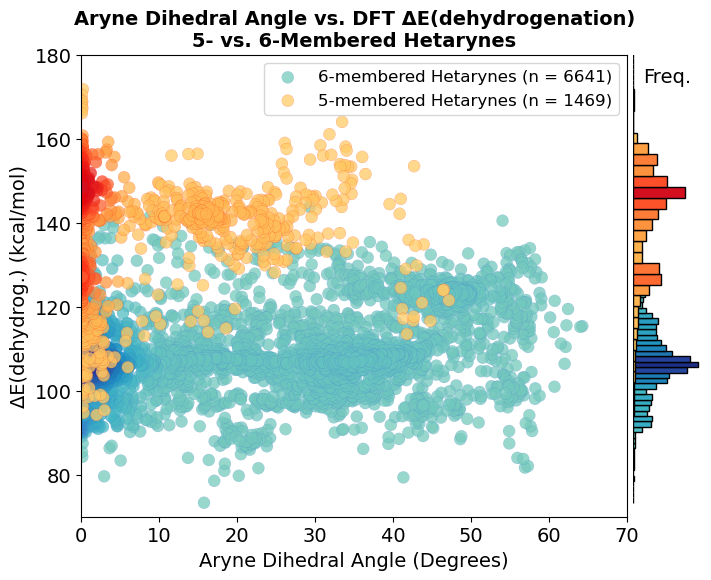

In [11]:
### Plot Aryne Dihedral Angle vs. Dehydration Energies ###
### 6-membered Rings ### 
x1_angles = six_data['Aryne_DiH_Ang']
y1_energies = six_data['dehydrogenation_energy']
xy1 = np.stack([x1_angles, y1_energies])
xy1_density = gaussian_kde(xy1)(xy1)
idx1 = xy1_density.argsort()
x1_angles, y1_energies, xy1_density = x1_angles[idx1], y1_energies[idx1], xy1_density[idx1]
#6mem_colormap
my_blu = plt.cm.YlGnBu(np.linspace(0.35,0.9,100))
my_blu = ListedColormap(my_blu[8:,:-1])

### 5-membered Rings ###
x_angles = five_data['Aryne_DiH_Ang']
y_energies = five_data['dehydrogenation_energy']
xy = np.stack([x_angles, y_energies])
xy_density = gaussian_kde(xy)(xy)
idx = xy_density.argsort()
x_angles, y_energies, xy_density = x_angles[idx], y_energies[idx], xy_density[idx]
#5-membered colormap
my_yrs = plt.cm.YlOrRd(np.linspace(0.25,0.8,100))
my_yrs = ListedColormap(my_yrs[8:,:-1])

##setting up the fig with subplots###
fig = plt.figure(figsize=(8, 6))
#set the relative spacing of the two subplots
gs = fig.add_gridspec(1, 2, width_ratios=(8, 1))
plt.subplots_adjust(wspace=0.02)

#initialize the subplots in their relative positions
ax_scatter = fig.add_subplot(gs[0, 0])
ax_hist_y = fig.add_subplot(gs[0, 1])

#plot the scatter data
#6-membered scatter data
ax_scatter.scatter(x1_angles, y1_energies, c=xy1_density, cmap=my_blu, linewidths=0.1,
                   edgecolors='royalblue', alpha=0.75, s=75, label='6-membered Hetarynes (n = 6641)')
                  
#5-membered scatter data
ax_scatter.scatter(x_angles, y_energies, c=xy_density, cmap=my_yrs, linewidths=0.1,
                   edgecolors='red', alpha=0.75, s=75, label='5-membered Hetarynes (n = 1469)')

#Plot Parameters for the left-side Scatterplot
ax_scatter.set_xlim(0,70)
ax_scatter.set_ylim(70,180)
ax_scatter.set_title("Aryne Dihedral Angle vs. DFT ΔE(dehydrogenation)\n5- vs. 6-Membered Hetarynes",
                     fontsize=14, fontweight='bold')

ax_scatter.set_xlabel("Aryne Dihedral Angle (Degrees)", fontsize=14)
ax_scatter.set_ylabel("ΔE(dehydrog.) (kcal/mol)", fontsize=14)
ax_scatter.tick_params(axis='both', which='major', labelsize=14)
ax_scatter.legend(loc='upper right', fontsize=12)


#plot Histo data - first is for 6 membered
m, bins, patches = ax_hist_y.hist(y1_energies, bins=100, density=True, edgecolor='black',
                                  label='6-membered Hetarynes', orientation='horizontal'
                                 )
bol = (m-m.min())/(m.max()-m.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_blu(c))

#plot Histo data - next is for 5 mem
n, bins, patches = ax_hist_y.hist(y_energies, bins=30, density=True, edgecolor='black',
                                  label='6-membered Hetarynes', orientation='horizontal'
                                 )
bol = (n-n.min())/(n.max()-n.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_yrs(c))

#set the y limit to match the scatter
ax_hist_y.set_ylim(70,180)

#Plot Parameters for the right-side Histogram
ax_hist_y.xaxis.set_label_position('top')
ax_hist_y.set_xlabel("Freq.", fontsize=14, labelpad=-20, loc='center')
ax_hist_y.set_yticks([])
ax_hist_y.set_xticks([])
#remove the lines around the histo plot
ax_hist_y.spines['top'].set_visible(False)
ax_hist_y.spines['bottom'].set_visible(False)
ax_hist_y.spines['right'].set_visible(False)
ax_hist_y.spines['left'].set_visible(False)

#output a copy of the plot to local drive
plt.savefig('5_vs_6_Aryne_Dihedral_angle_vs_dEdehyd_with_histos.png', bbox_inches="tight",
            transparent=True, dpi=600
           )
plt.show()

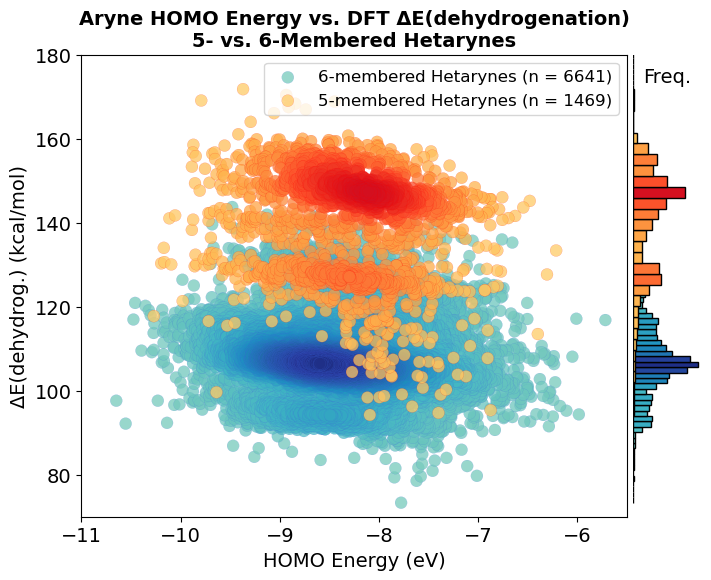

In [12]:
### Plot Aryne HOMO Energy vs. Dehydration Energies ###
### 6-membered Rings ### 
x1_angles = six_data['eHOMO(eV)']
y1_energies = six_data['dehydrogenation_energy']
xy1 = np.stack([x1_angles, y1_energies])
xy1_density = gaussian_kde(xy1)(xy1)
idx1 = xy1_density.argsort()
x1_angles, y1_energies, xy1_density = x1_angles[idx1], y1_energies[idx1], xy1_density[idx1]
#6mem_colormap
my_blu = plt.cm.YlGnBu(np.linspace(0.35,0.9,100))
my_blu = ListedColormap(my_blu[8:,:-1])

### 5-membered Rings ###
x_angles = five_data['eHOMO(eV)']
y_energies = five_data['dehydrogenation_energy']
xy = np.stack([x_angles, y_energies])
xy_density = gaussian_kde(xy)(xy)
idx = xy_density.argsort()
x_angles, y_energies, xy_density = x_angles[idx], y_energies[idx], xy_density[idx]
#5-membered colormap
my_yrs = plt.cm.YlOrRd(np.linspace(0.25,0.8,100))
my_yrs = ListedColormap(my_yrs[8:,:-1])

##setting up the fig with subplots###
fig = plt.figure(figsize=(8, 6))
#set the relative spacing of the two subplots
gs = fig.add_gridspec(1, 2, width_ratios=(8, 1))
plt.subplots_adjust(wspace=0.02)

#initialize the subplots in their relative positions
ax_scatter = fig.add_subplot(gs[0, 0])
ax_hist_y = fig.add_subplot(gs[0, 1])

#plot the scatter data
#6-membered scatter data
ax_scatter.scatter(x1_angles, y1_energies, c=xy1_density, cmap=my_blu, linewidths=0.1,
                   edgecolors='royalblue', alpha=0.75, s=75, label='6-membered Hetarynes (n = 6641)')
                  
#5-membered scatter data
ax_scatter.scatter(x_angles, y_energies, c=xy_density, cmap=my_yrs, linewidths=0.1,
                   edgecolors='red', alpha=0.75, s=75, label='5-membered Hetarynes (n = 1469)')

#Plot Parameters for the left-side Scatterplot
ax_scatter.set_xlim(-11,-5.5)
ax_scatter.set_ylim(70,180)
ax_scatter.set_title("Aryne HOMO Energy vs. DFT ΔE(dehydrogenation)\n5- vs. 6-Membered Hetarynes",
                     fontsize=14, fontweight='bold'
                    )
ax_scatter.set_xlabel("HOMO Energy (eV)", fontsize=14)
ax_scatter.set_ylabel("ΔE(dehydrog.) (kcal/mol)", fontsize=14)
ax_scatter.tick_params(axis='both', which='major', labelsize=14)
ax_scatter.legend(loc='upper right', fontsize=12)


#plot Histo data - first is for 6 membered
m, bins, patches = ax_hist_y.hist(y1_energies, bins=100, density=True, edgecolor='black',
                                  label='6-membered Hetarynes', orientation='horizontal'
                                 )
bol = (m-m.min())/(m.max()-m.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_blu(c))

#plot Histo data - next is for 5 mem
n, bins, patches = ax_hist_y.hist(y_energies, bins=30, density=True, edgecolor='black',
                                  label='6-membered Hetarynes', orientation='horizontal'
                                 )
bol = (n-n.min())/(n.max()-n.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_yrs(c))

#set the y limit to match the scatter
ax_hist_y.set_ylim(70,180)

#Plot Parameters for the right-side Histogram
ax_hist_y.xaxis.set_label_position('top')
ax_hist_y.set_xlabel("Freq.", fontsize=14, labelpad=-20, loc='center')
ax_hist_y.set_yticks([])
ax_hist_y.set_xticks([])
#remove the lines around the histo plot
ax_hist_y.spines['top'].set_visible(False)
ax_hist_y.spines['bottom'].set_visible(False)
ax_hist_y.spines['right'].set_visible(False)
ax_hist_y.spines['left'].set_visible(False)

#output a copy of the plot to local drive
plt.savefig('5_vs_6_Aryne_HOMO_Energy_vs_dEdehyd_with_histos.png', bbox_inches="tight",
            transparent=True, dpi=600
           )
plt.show()

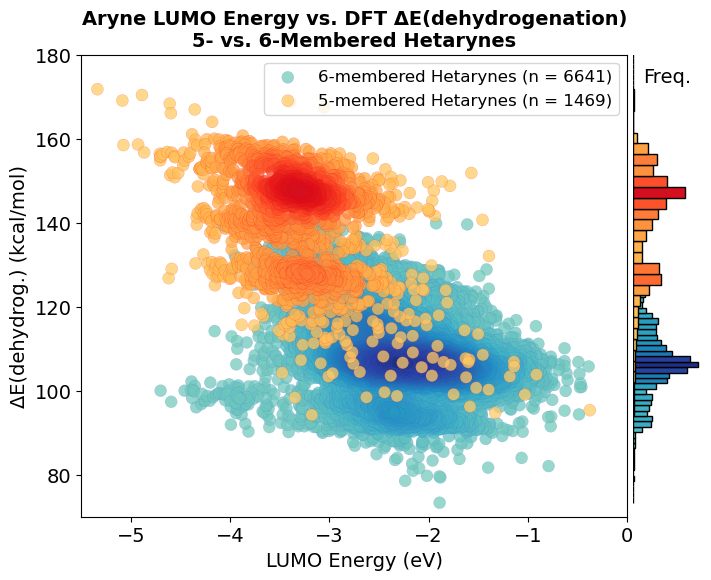

In [13]:
### Plot Aryne LUMO Energy vs. Dehydration Energies ###
### 6-membered Rings ### 
x1_angles = six_data['eLUMO(eV)']
y1_energies = six_data['dehydrogenation_energy']
xy1 = np.stack([x1_angles, y1_energies])
xy1_density = gaussian_kde(xy1)(xy1)
idx1 = xy1_density.argsort()
x1_angles, y1_energies, xy1_density = x1_angles[idx1], y1_energies[idx1], xy1_density[idx1]
#6mem_colormap
my_blu = plt.cm.YlGnBu(np.linspace(0.35,0.9,100))
my_blu = ListedColormap(my_blu[8:,:-1])

### 5-membered Rings ###
x_angles = five_data['eLUMO(eV)']
y_energies = five_data['dehydrogenation_energy']
xy = np.stack([x_angles, y_energies])
xy_density = gaussian_kde(xy)(xy)
idx = xy_density.argsort()
x_angles, y_energies, xy_density = x_angles[idx], y_energies[idx], xy_density[idx]
#5-membered colormap
my_yrs = plt.cm.YlOrRd(np.linspace(0.25,0.8,100))
my_yrs = ListedColormap(my_yrs[8:,:-1])

##setting up the fig with subplots###
fig = plt.figure(figsize=(8, 6))
#set the relative spacing of the two subplots
gs = fig.add_gridspec(1, 2, width_ratios=(8, 1))
plt.subplots_adjust(wspace=0.02)

#initialize the subplots in their relative positions
ax_scatter = fig.add_subplot(gs[0, 0])
ax_hist_y = fig.add_subplot(gs[0, 1])

#plot the scatter data
#6-membered scatter data
ax_scatter.scatter(x1_angles, y1_energies, c=xy1_density, cmap=my_blu, linewidths=0.1,
                   edgecolors='royalblue', alpha=0.75, s=75, label='6-membered Hetarynes (n = 6641)')
                  
#5-membered scatter data
ax_scatter.scatter(x_angles, y_energies, c=xy_density, cmap=my_yrs, linewidths=0.1,
                   edgecolors='red', alpha=0.75, s=75, label='5-membered Hetarynes (n = 1469)')

#Plot Parameters for the left-side Scatterplot
ax_scatter.set_xlim(-5.5,0)
ax_scatter.set_ylim(70,180)
ax_scatter.set_title("Aryne LUMO Energy vs. DFT ΔE(dehydrogenation)\n5- vs. 6-Membered Hetarynes",
                     fontsize=14, fontweight='bold'
                    )
ax_scatter.set_xlabel("LUMO Energy (eV)", fontsize=14)
ax_scatter.set_ylabel("ΔE(dehydrog.) (kcal/mol)", fontsize=14)
ax_scatter.tick_params(axis='both', which='major', labelsize=14)
ax_scatter.legend(loc='upper right', fontsize=12)


#plot Histo data - first is for 6 membered
m, bins, patches = ax_hist_y.hist(y1_energies, bins=100, density=True, edgecolor='black',
                                  label='6-membered Hetarynes', orientation='horizontal'
                                 )
bol = (m-m.min())/(m.max()-m.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_blu(c))

#plot Histo data - next is for 5 mem
n, bins, patches = ax_hist_y.hist(y_energies, bins=30, density=True, edgecolor='black',
                                  label='6-membered Hetarynes', orientation='horizontal'
                                 )
bol = (n-n.min())/(n.max()-n.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_yrs(c))

#set the y limit to match the scatter
ax_hist_y.set_ylim(70,180)

#Plot Parameters for the right-side Histogram
ax_hist_y.xaxis.set_label_position('top')
ax_hist_y.set_xlabel("Freq.", fontsize=14, labelpad=-20, loc='center')
ax_hist_y.set_yticks([])
ax_hist_y.set_xticks([])
#remove the lines around the histo plot
ax_hist_y.spines['top'].set_visible(False)
ax_hist_y.spines['bottom'].set_visible(False)
ax_hist_y.spines['right'].set_visible(False)
ax_hist_y.spines['left'].set_visible(False)

#output a copy of the plot to local drive
plt.savefig('5_vs_6_Aryne_LUMO_Energy_vs_dEdehyd_with_histos.png', bbox_inches="tight",
            transparent=True, dpi=600
           )
plt.show()

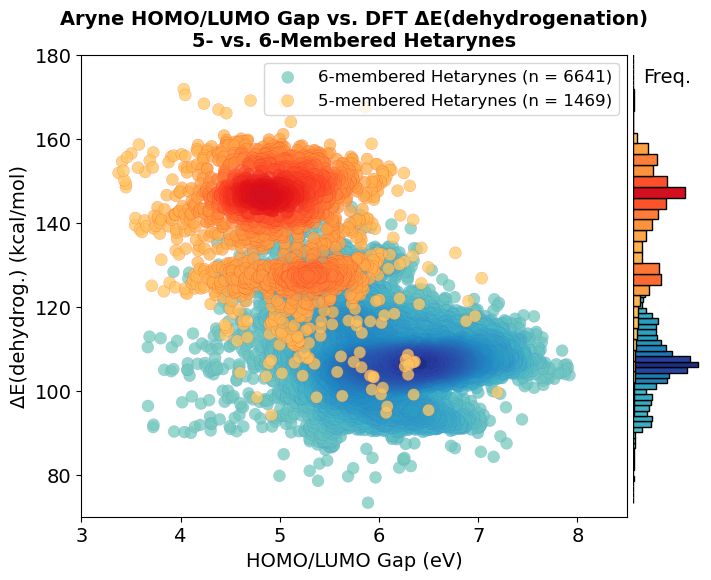

In [14]:
### Plot Aryne HOMO/LUMO Gap vs. Dehydration Energies ###
### 6-membered Rings ### 
x1_angles = six_data['H_L_Gap(eV)']
y1_energies = six_data['dehydrogenation_energy']
xy1 = np.stack([x1_angles, y1_energies])
xy1_density = gaussian_kde(xy1)(xy1)
idx1 = xy1_density.argsort()
x1_angles, y1_energies, xy1_density = x1_angles[idx1], y1_energies[idx1], xy1_density[idx1]
#6mem_colormap
my_blu = plt.cm.YlGnBu(np.linspace(0.35,0.9,100))
my_blu = ListedColormap(my_blu[8:,:-1])

### 5-membered Rings ###
x_angles = five_data['H_L_Gap(eV)']
y_energies = five_data['dehydrogenation_energy']
xy = np.stack([x_angles, y_energies])
xy_density = gaussian_kde(xy)(xy)
idx = xy_density.argsort()
x_angles, y_energies, xy_density = x_angles[idx], y_energies[idx], xy_density[idx]
#5-membered colormap
my_yrs = plt.cm.YlOrRd(np.linspace(0.25,0.8,100))
my_yrs = ListedColormap(my_yrs[8:,:-1])

##setting up the fig with subplots###
fig = plt.figure(figsize=(8, 6))
#set the relative spacing of the two subplots
gs = fig.add_gridspec(1, 2, width_ratios=(8, 1))
plt.subplots_adjust(wspace=0.02)

#initialize the subplots in their relative positions
ax_scatter = fig.add_subplot(gs[0, 0])
ax_hist_y = fig.add_subplot(gs[0, 1])

#plot the scatter data
#6-membered scatter data
ax_scatter.scatter(x1_angles, y1_energies, c=xy1_density, cmap=my_blu, linewidths=0.1,
                   edgecolors='royalblue', alpha=0.75, s=75, label='6-membered Hetarynes (n = 6641)')
                  
#5-membered scatter data
ax_scatter.scatter(x_angles, y_energies, c=xy_density, cmap=my_yrs, linewidths=0.1,
                   edgecolors='red', alpha=0.75, s=75, label='5-membered Hetarynes (n = 1469)')

#Plot Parameters for the left-side Scatterplot
ax_scatter.set_xlim(3,8.5)
ax_scatter.set_ylim(70,180)
ax_scatter.set_title("Aryne HOMO/LUMO Gap vs. DFT ΔE(dehydrogenation)\n5- vs. 6-Membered Hetarynes",
                     fontsize=14, fontweight='bold'
                    )
ax_scatter.set_xlabel("HOMO/LUMO Gap (eV)", fontsize=14)
ax_scatter.set_ylabel("ΔE(dehydrog.) (kcal/mol)", fontsize=14)
ax_scatter.tick_params(axis='both', which='major', labelsize=14)
ax_scatter.legend(loc='upper right', fontsize=12)

#plot Histo data - first is for 6 membered
m, bins, patches = ax_hist_y.hist(y1_energies, bins=100, density=True, edgecolor='black',
                                  label='6-membered Hetarynes', orientation='horizontal'
                                 )
bol = (m-m.min())/(m.max()-m.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_blu(c))

#plot Histo data - next is for 5 mem
n, bins, patches = ax_hist_y.hist(y_energies, bins=30, density=True, edgecolor='black',
                                  label='6-membered Hetarynes', orientation='horizontal'
                                 )
bol = (n-n.min())/(n.max()-n.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_yrs(c))

#set the y limit to match the scatter
ax_hist_y.set_ylim(70,180)

#Plot Parameters for the right-side Histogram
ax_hist_y.xaxis.set_label_position('top')
ax_hist_y.set_xlabel("Freq.", fontsize=14, labelpad=-20, loc='center')
ax_hist_y.set_yticks([])
ax_hist_y.set_xticks([])
#remove the lines around the histo plot
ax_hist_y.spines['top'].set_visible(False)
ax_hist_y.spines['bottom'].set_visible(False)
ax_hist_y.spines['right'].set_visible(False)
ax_hist_y.spines['left'].set_visible(False)

#output a copy of the plot to local drive
plt.savefig('5_vs_6_Aryne_HOMO-LUMO_Gap_vs_dEdehyd_with_histos.png', bbox_inches="tight",
            transparent=True, dpi=600
           )
plt.show()

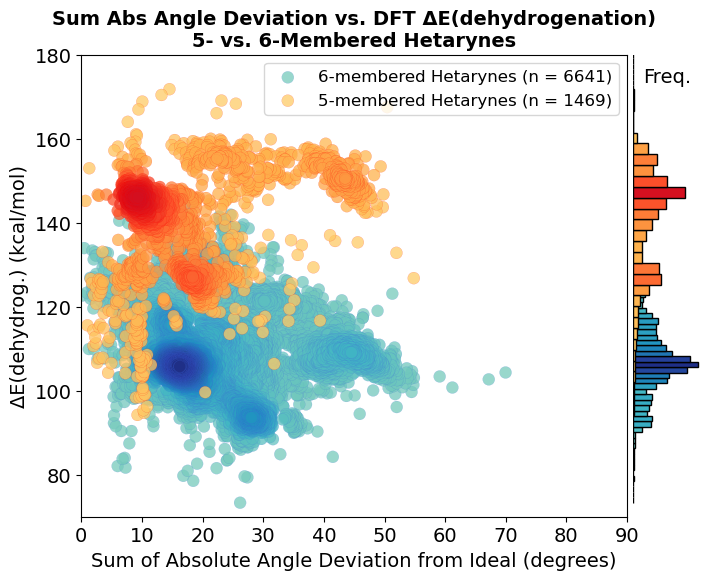

In [15]:
### Plot Aryne Sum of Absolute Deviation vs. Dehydration Energies ###
### 6-membered Rings ### 
x1_angles = six_data['Sum_abs_dev']
y1_energies = six_data['dehydrogenation_energy']
xy1 = np.stack([x1_angles, y1_energies])
xy1_density = gaussian_kde(xy1)(xy1)
idx1 = xy1_density.argsort()
x1_angles, y1_energies, xy1_density = x1_angles[idx1], y1_energies[idx1], xy1_density[idx1]
#6mem_colormap
my_blu = plt.cm.YlGnBu(np.linspace(0.35,0.9,100))
my_blu = ListedColormap(my_blu[8:,:-1])

### 5-membered Rings ###
x_angles = five_data['Sum_abs_dev']
y_energies = five_data['dehydrogenation_energy']
xy = np.stack([x_angles, y_energies])
xy_density = gaussian_kde(xy)(xy)
idx = xy_density.argsort()
x_angles, y_energies, xy_density = x_angles[idx], y_energies[idx], xy_density[idx]
#5-membered colormap
my_yrs = plt.cm.YlOrRd(np.linspace(0.25,0.8,100))
my_yrs = ListedColormap(my_yrs[8:,:-1])

##setting up the fig with subplots###
fig = plt.figure(figsize=(8, 6))
#set the relative spacing of the two subplots
gs = fig.add_gridspec(1, 2, width_ratios=(8, 1))
plt.subplots_adjust(wspace=0.02)

#initialize the subplots in their relative positions
ax_scatter = fig.add_subplot(gs[0, 0])
ax_hist_y = fig.add_subplot(gs[0, 1])

#plot the scatter data
#6-membered scatter data
ax_scatter.scatter(x1_angles, y1_energies, c=xy1_density, cmap=my_blu, linewidths=0.1,
                   edgecolors='royalblue', alpha=0.75, s=75, label='6-membered Hetarynes (n = 6641)')
                  
#5-membered scatter data
ax_scatter.scatter(x_angles, y_energies, c=xy_density, cmap=my_yrs, linewidths=0.1,
                   edgecolors='red', alpha=0.75, s=75, label='5-membered Hetarynes (n = 1469)')

#Plot Parameters for the left-side Scatterplot
ax_scatter.set_xlim(0,90)
ax_scatter.set_ylim(70,180)
ax_scatter.set_title("Sum Abs Angle Deviation vs. DFT ΔE(dehydrogenation)\n5- vs. 6-Membered Hetarynes",
                     fontsize=14, fontweight='bold'
                    )
ax_scatter.set_xlabel("Sum of Absolute Angle Deviation from Ideal (degrees)", fontsize=14)
ax_scatter.set_ylabel("ΔE(dehydrog.) (kcal/mol)", fontsize=14)
ax_scatter.tick_params(axis='both', which='major', labelsize=14)
ax_scatter.legend(loc='upper right', fontsize=12)

#plot Histo data - first is for 6 membered
m, bins, patches = ax_hist_y.hist(y1_energies, bins=100, density=True, edgecolor='black',
                                  label='6-membered Hetarynes', orientation='horizontal'
                                 )
bol = (m-m.min())/(m.max()-m.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_blu(c))

#plot Histo data - next is for 5 mem
n, bins, patches = ax_hist_y.hist(y_energies, bins=30, density=True, edgecolor='black',
                                  label='6-membered Hetarynes', orientation='horizontal'
                                 )
bol = (n-n.min())/(n.max()-n.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_yrs(c))

#set the y limit to match the scatter
ax_hist_y.set_ylim(70,180)

#Plot Parameters for the right-side Histogram
ax_hist_y.xaxis.set_label_position('top')
ax_hist_y.set_xlabel("Freq.", fontsize=14, labelpad=-20, loc='center')
ax_hist_y.set_yticks([])
ax_hist_y.set_xticks([])
#remove the lines around the histo plot
ax_hist_y.spines['top'].set_visible(False)
ax_hist_y.spines['bottom'].set_visible(False)
ax_hist_y.spines['right'].set_visible(False)
ax_hist_y.spines['left'].set_visible(False)

#output a copy of the plot to local drive
plt.savefig('5_vs_6_Sum_of_Absolute_Deviation_of_Aryne_vs_dEdehyd_with_histos.png', bbox_inches="tight",
            transparent=True, dpi=600
           )
plt.show()

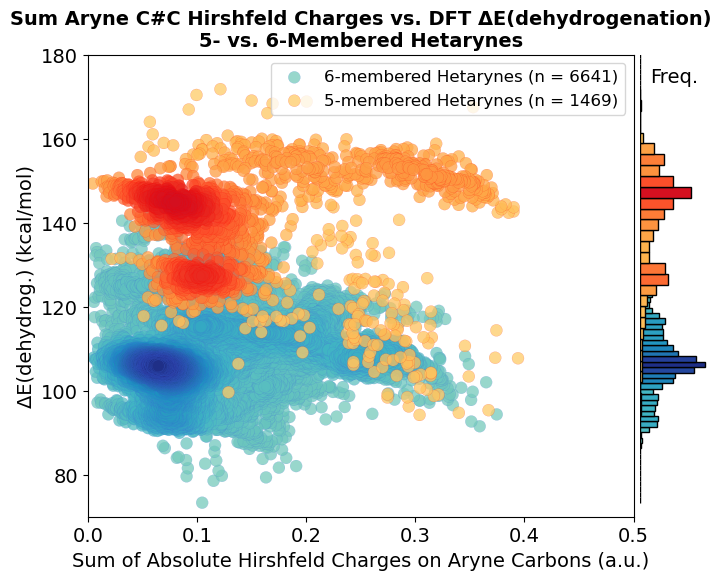

In [16]:
### Plot Aryne Sum of Absolute Deviation vs. Dehydration Energies ###
### 6-membered Rings ### 
x1_angles = six_data['Sum_Abs_Hirsh_aryne']
y1_energies = six_data['dehydrogenation_energy']
xy1 = np.stack([x1_angles, y1_energies])
xy1_density = gaussian_kde(xy1)(xy1)
idx1 = xy1_density.argsort()
x1_angles, y1_energies, xy1_density = x1_angles[idx1], y1_energies[idx1], xy1_density[idx1]
#6mem_colormap
my_blu = plt.cm.YlGnBu(np.linspace(0.35,0.9,100))
my_blu = ListedColormap(my_blu[8:,:-1])

### 5-membered Rings ###
x_angles = five_data['Sum_Abs_Hirsh_aryne']
y_energies = five_data['dehydrogenation_energy']
xy = np.stack([x_angles, y_energies])
xy_density = gaussian_kde(xy)(xy)
idx = xy_density.argsort()
x_angles, y_energies, xy_density = x_angles[idx], y_energies[idx], xy_density[idx]
#5-membered colormap
my_yrs = plt.cm.YlOrRd(np.linspace(0.25,0.8,100))
my_yrs = ListedColormap(my_yrs[8:,:-1])

##setting up the fig with subplots###
fig = plt.figure(figsize=(8, 6))
#set the relative spacing of the two subplots
gs = fig.add_gridspec(1, 2, width_ratios=(8, 1))
plt.subplots_adjust(wspace=0.02)

#initialize the subplots in their relative positions
ax_scatter = fig.add_subplot(gs[0, 0])
ax_hist_y = fig.add_subplot(gs[0, 1])

#plot the scatter data
#6-membered scatter data
ax_scatter.scatter(x1_angles, y1_energies, c=xy1_density, cmap=my_blu, linewidths=0.1,
                   edgecolors='royalblue', alpha=0.75, s=75, label='6-membered Hetarynes (n = 6641)')
                  
#5-membered scatter data
ax_scatter.scatter(x_angles, y_energies, c=xy_density, cmap=my_yrs, linewidths=0.1,
                   edgecolors='red', alpha=0.75, s=75, label='5-membered Hetarynes (n = 1469)')

#Plot Parameters for the left-side Scatterplot
ax_scatter.set_xlim(0,0.5)
ax_scatter.set_ylim(70,180)
ax_scatter.set_title("Sum Aryne C#C Hirshfeld Charges vs. DFT ΔE(dehydrogenation)\n5- vs. 6-Membered Hetarynes",
                     fontsize=14, fontweight='bold'
                    )
ax_scatter.set_xlabel("Sum of Absolute Hirshfeld Charges on Aryne Carbons (a.u.)", fontsize=14)
ax_scatter.set_ylabel("ΔE(dehydrog.) (kcal/mol)", fontsize=14)
ax_scatter.tick_params(axis='both', which='major', labelsize=14)
ax_scatter.legend(loc='upper right', fontsize=12)

#plot Histo data - first is for 6 membered
m, bins, patches = ax_hist_y.hist(y1_energies, bins=100, density=True, edgecolor='black',
                                  label='6-membered Hetarynes', orientation='horizontal'
                                 )
bol = (m-m.min())/(m.max()-m.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_blu(c))

#plot Histo data - next is for 5 mem
n, bins, patches = ax_hist_y.hist(y_energies, bins=30, density=True, edgecolor='black',
                                  label='6-membered Hetarynes', orientation='horizontal'
                                 )
bol = (n-n.min())/(n.max()-n.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_yrs(c))

#set the y limit to match the scatter
ax_hist_y.set_ylim(70,180)

#Plot Parameters for the right-side Histogram
ax_hist_y.xaxis.set_label_position('top')
ax_hist_y.set_xlabel("Freq.", fontsize=14, labelpad=-20, loc='center')
ax_hist_y.set_yticks([])
ax_hist_y.set_xticks([])
#remove the lines around the histo plot
ax_hist_y.spines['top'].set_visible(False)
ax_hist_y.spines['bottom'].set_visible(False)
ax_hist_y.spines['right'].set_visible(False)
ax_hist_y.spines['left'].set_visible(False)

#output a copy of the plot to local drive
plt.savefig('5_vs_6_Sum_of_Aryne_Hirshfeld_Charges_vs_dEdehyd_with_histos.png', bbox_inches="tight",
            transparent=True, dpi=600
           )
plt.show()

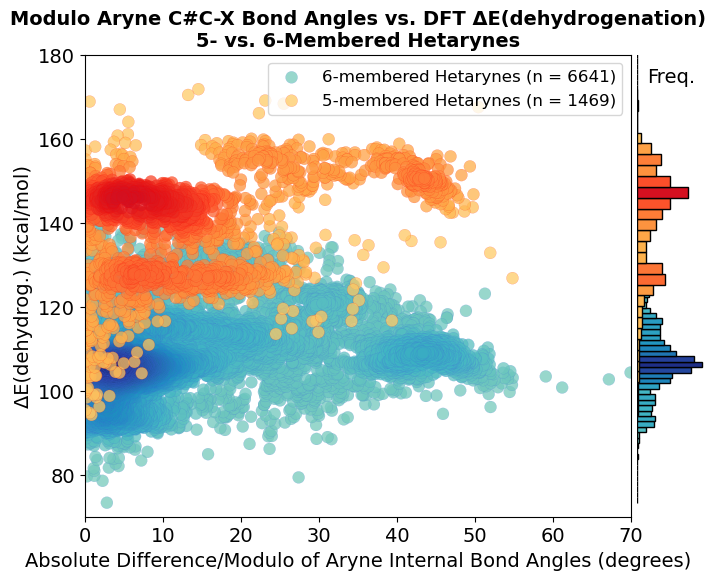

In [5]:
### Plot Aryne Modulo Bond Angles vs. Dehydration Energies ###
### 6-membered Rings ### 
x1_angles = six_data['Abs_Dif_Bnd_Angl']
y1_energies = six_data['dehydrogenation_energy']
xy1 = np.stack([x1_angles, y1_energies])
xy1_density = gaussian_kde(xy1)(xy1)
idx1 = xy1_density.argsort()
x1_angles, y1_energies, xy1_density = x1_angles[idx1], y1_energies[idx1], xy1_density[idx1]
#6mem_colormap
my_blu = plt.cm.YlGnBu(np.linspace(0.35,0.9,100))
my_blu = ListedColormap(my_blu[8:,:-1])

### 5-membered Rings ###
x_angles = five_data['Abs_Dif_Bnd_Angl']
y_energies = five_data['dehydrogenation_energy']
xy = np.stack([x_angles, y_energies])
xy_density = gaussian_kde(xy)(xy)
idx = xy_density.argsort()
x_angles, y_energies, xy_density = x_angles[idx], y_energies[idx], xy_density[idx]
#5-membered colormap
my_yrs = plt.cm.YlOrRd(np.linspace(0.25,0.8,100))
my_yrs = ListedColormap(my_yrs[8:,:-1])

##setting up the fig with subplots###
fig = plt.figure(figsize=(8, 6))
#set the relative spacing of the two subplots
gs = fig.add_gridspec(1, 2, width_ratios=(8, 1))
plt.subplots_adjust(wspace=0.02)

#initialize the subplots in their relative positions
ax_scatter = fig.add_subplot(gs[0, 0])
ax_hist_y = fig.add_subplot(gs[0, 1])

#plot the scatter data
#6-membered scatter data
ax_scatter.scatter(x1_angles, y1_energies, c=xy1_density, cmap=my_blu, linewidths=0.1,
                   edgecolors='royalblue', alpha=0.75, s=75, label='6-membered Hetarynes (n = 6641)')
                  
#5-membered scatter data
ax_scatter.scatter(x_angles, y_energies, c=xy_density, cmap=my_yrs, linewidths=0.1,
                   edgecolors='red', alpha=0.75, s=75, label='5-membered Hetarynes (n = 1469)')

#Plot Parameters for the left-side Scatterplot
ax_scatter.set_xlim(0,70)
ax_scatter.set_ylim(70,180)
ax_scatter.set_title("Modulo Aryne C#C-X Bond Angles vs. DFT ΔE(dehydrogenation)\n5- vs. 6-Membered Hetarynes",
                     fontsize=14, fontweight='bold'
                    )
ax_scatter.set_xlabel("Absolute Difference/Modulo of Aryne Internal Bond Angles (degrees)", fontsize=14)
ax_scatter.set_ylabel("ΔE(dehydrog.) (kcal/mol)", fontsize=14)
ax_scatter.tick_params(axis='both', which='major', labelsize=14)
ax_scatter.legend(loc='upper right', fontsize=12)

#plot Histo data - first is for 6 membered
m, bins, patches = ax_hist_y.hist(y1_energies, bins=100, density=True, edgecolor='black',
                                  label='6-membered Hetarynes', orientation='horizontal'
                                 )
bol = (m-m.min())/(m.max()-m.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_blu(c))

#plot Histo data - next is for 5 mem
n, bins, patches = ax_hist_y.hist(y_energies, bins=30, density=True, edgecolor='black',
                                  label='6-membered Hetarynes', orientation='horizontal'
                                 )
bol = (n-n.min())/(n.max()-n.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_yrs(c))

#set the y limit to match the scatter
ax_hist_y.set_ylim(70,180)

#Plot Parameters for the right-side Histogram
ax_hist_y.xaxis.set_label_position('top')
ax_hist_y.set_xlabel("Freq.", fontsize=14, labelpad=-20, loc='center')
ax_hist_y.set_yticks([])
ax_hist_y.set_xticks([])
#remove the lines around the histo plot
ax_hist_y.spines['top'].set_visible(False)
ax_hist_y.spines['bottom'].set_visible(False)
ax_hist_y.spines['right'].set_visible(False)
ax_hist_y.spines['left'].set_visible(False)

#output a copy of the plot to local drive
plt.savefig('5_vs_6_Modulo_Aryne_Bond_Angles_vs_dEdehyd_with_histos.png', bbox_inches="tight",
            transparent=True, dpi=600
           )
plt.show()

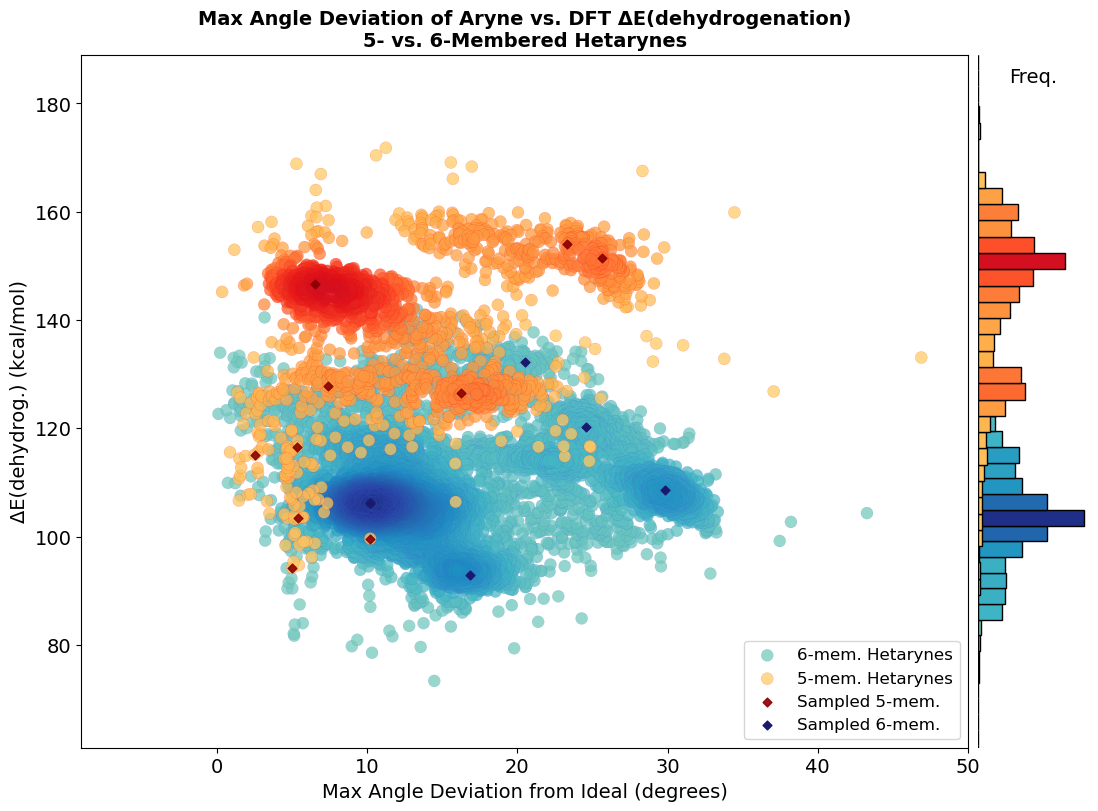

In [63]:
### Large Plot with Specified Arynes at Certain Clusters - Maximum Angle Deviation vs. Dehyd. Energies ###
#Use this to make a plot with sampled arynes; can add them manually after as overlay

#Gather relevant data and format colors for each group of arynes
### 6-membered Rings ### 
x1_angles = six_data['Max_angle_dev']
y1_energies = six_data['dehydrogenation_energy']
xy1 = np.stack([x1_angles, y1_energies])
xy1_density = gaussian_kde(xy1)(xy1)
idx1 = xy1_density.argsort()
x1_angles, y1_energies, xy1_density = x1_angles[idx1], y1_energies[idx1], xy1_density[idx1]
#6mem_colormap
my_blu = plt.cm.YlGnBu(np.linspace(0.35,0.9,100))
my_blu = ListedColormap(my_blu[8:,:-1])

### 5-membered Rings ###
x_angles = five_data['Max_angle_dev']
y_energies = five_data['dehydrogenation_energy']
xy = np.stack([x_angles, y_energies])
xy_density = gaussian_kde(xy)(xy)
idx = xy_density.argsort()
x_angles, y_energies, xy_density = x_angles[idx], y_energies[idx], xy_density[idx]
#5-membered colormap
my_yrs = plt.cm.YlOrRd(np.linspace(0.25,0.8,100))
my_yrs = ListedColormap(my_yrs[8:,:-1])

### Specify targeted Arynes based on value you see in the plots ### 
#These are selected arynes targeting certain clusters
five_samples = ['aryne_4374',
               'aryne_2104',
               'aryne_8224',
               'aryne_6162',
               'aryne_4663',
                #below here are quite stable 5-mem arynes
                'aryne_959',
                'aryne_2352',
                'aryne_75',
                'aryne_1546',
                'aryne_5299',
               ]

#grab the data associated with these specified arynes
tgt_x = five_data.loc[five_data['aryne_id'].isin(five_samples), 'Max_angle_dev']
tgt_y = five_data.loc[five_data['aryne_id'].isin(five_samples), 'dehydrogenation_energy']

#These are selected arynes targeting certain clusters
six_samples = ['aryne_9290',
               'aryne_246',
               'aryne_4644',
               'aryne_8543',
               'aryne_764',
               ]

#grab the data associated with these specified arynes
six_x = six_data.loc[six_data['aryne_id'].isin(six_samples), 'Max_angle_dev']
six_y = six_data.loc[six_data['aryne_id'].isin(six_samples), 'dehydrogenation_energy']


### Plotting the Gathered Data ### 
##setting up the fig with subplots###
fig = plt.figure(figsize=(13, 9))
#set the relative spacing of the two subplots
gs = fig.add_gridspec(1, 2, width_ratios=(8, 1))
plt.subplots_adjust(wspace=0.02)

#initialize the subplots in their relative positions
ax_scatter = fig.add_subplot(gs[0, 0])
ax_hist_y = fig.add_subplot(gs[0, 1])


### Left-Side Scatter Plot ### 
#plot the scatter data
#6-membered scatter data
ax_scatter.scatter(x1_angles, y1_energies, c=xy1_density, cmap=my_blu, linewidths=0.1,
                   edgecolors='royalblue', alpha=0.75, s=75, label='6-mem. Hetarynes',
                  )
#5-membered scatter data
ax_scatter.scatter(x_angles, y_energies, c=xy_density, cmap=my_yrs, linewidths=0.1,
                   edgecolors='red', alpha=0.75, s=75, label='5-mem. Hetarynes',
                  )

#Plot the sampled points for 5- and 6-membered hetarynes
ax_scatter.scatter(tgt_x, tgt_y, c='darkred', alpha=0.9, s=20, marker='D', label='Sampled 5-mem.')
ax_scatter.scatter(six_x, six_y, c='midnightblue', alpha=1, s=20, marker='D', label='Sampled 6-mem.')

#Plot Parameters for the left-side Scatterplot
ax_scatter.set_xlim(-9,50)
ax_scatter.set_ylim(61,189)
ax_scatter.set_title("Max Angle Deviation of Aryne vs. DFT ΔE(dehydrogenation)\n5- vs. 6-Membered Hetarynes",
                     fontsize=14, fontweight='bold'
                    )
ax_scatter.set_xlabel("Max Angle Deviation from Ideal (degrees)", fontsize=14)
ax_scatter.set_ylabel("ΔE(dehydrog.) (kcal/mol)", fontsize=14)
ax_scatter.tick_params(axis='both', which='major', labelsize=14)
ax_scatter.legend(loc='lower right', fontsize=12)
#handles, labels = ax_scatter.get_legend_handles_labels()
# #print(labels)
# reordered_handles = [handles[i] for i in [0, 2, 1]]
# reordered_labels = [labels[i] for i in [0, 2, 1]]
# ax_scatter.legend(reordered_handles, reordered_labels, fontsize=14)


#plot Histo data - first is for 6 membered
m, bins, patches = ax_hist_y.hist(y1_energies, bins=100, density=True, edgecolor='black',
                                  label='6-membered Hetarynes', orientation='horizontal'
                                 )
bol = (m-m.min())/(m.max()-m.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_blu(c))

#plot Histo data - next is for 5 mem
n, bins, patches = ax_hist_y.hist(y_energies, bins=30, density=True, edgecolor='black',
                                  label='6-membered Hetarynes', orientation='horizontal'
                                 )
bol = (n-n.min())/(n.max()-n.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_yrs(c))

#set the y limit to match the scatter
ax_hist_y.set_ylim(70,180)

#Plot Parameters for the right-side Histogram
ax_hist_y.xaxis.set_label_position('top')
ax_hist_y.set_xlabel("Freq.", fontsize=14, labelpad=-20, loc='center')
ax_hist_y.set_yticks([])
ax_hist_y.set_xticks([])
#remove the lines around the histo plot
ax_hist_y.spines['top'].set_visible(False)
ax_hist_y.spines['bottom'].set_visible(False)
ax_hist_y.spines['right'].set_visible(False)
ax_hist_y.spines['left'].set_visible(False)
#Save the figure locally
plt.savefig('Big_Version_Max_Angle_Dev_vs_dEdehyd.png', bbox_inches="tight", transparent=True, dpi=600)
plt.show()

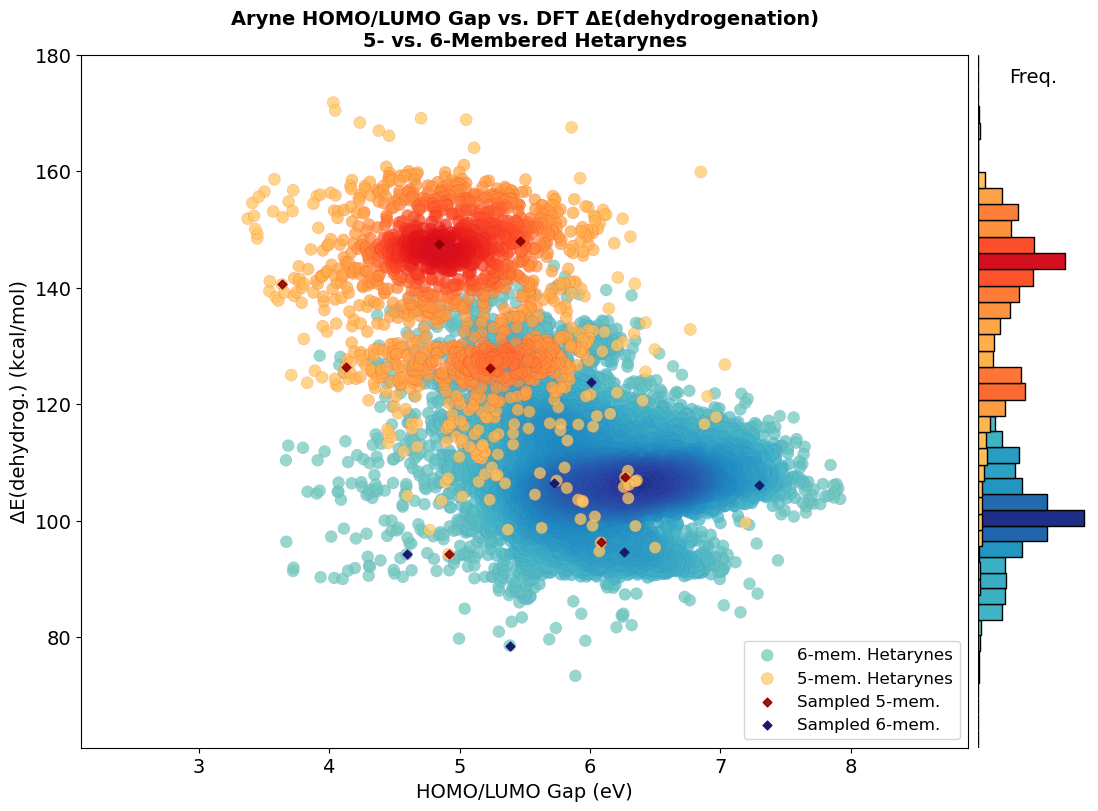

In [64]:
### Large Plot with Specified Arynes at Certain Clusters - HOMO/LUMO Gap vs. Dehyd. Energies ###
#Use this to make a plot with sampled arynes; can add them manually after as overlay

#Gather relevant data and format colors for each group of arynes
### 6-membered Rings ### 
x1_angles = six_data['H_L_Gap(eV)']
y1_energies = six_data['dehydrogenation_energy']
xy1 = np.stack([x1_angles, y1_energies])
xy1_density = gaussian_kde(xy1)(xy1)
idx1 = xy1_density.argsort()
x1_angles, y1_energies, xy1_density = x1_angles[idx1], y1_energies[idx1], xy1_density[idx1]
#6mem_colormap
my_blu = plt.cm.YlGnBu(np.linspace(0.35,0.9,100))
my_blu = ListedColormap(my_blu[8:,:-1])

### 5-membered Rings ###
x_angles = five_data['H_L_Gap(eV)']
y_energies = five_data['dehydrogenation_energy']
xy = np.stack([x_angles, y_energies])
xy_density = gaussian_kde(xy)(xy)
idx = xy_density.argsort()
x_angles, y_energies, xy_density = x_angles[idx], y_energies[idx], xy_density[idx]
#5-membered colormap
my_yrs = plt.cm.YlOrRd(np.linspace(0.25,0.8,100))
my_yrs = ListedColormap(my_yrs[8:,:-1])

# ### Specify targeted Arynes based on value you see in the plots ### 
# #These are selected arynes targeting certain clusters
# #These are selected arynes targeting certain clusters (these selected arynes are the same
# #as the ones sampled above in the other plot; note that they shift considerably, here
# five_samples = ['aryne_4374',
#                'aryne_2104',
#                'aryne_8224',
#                'aryne_6162',
#                'aryne_4663',
#                 #below here are quite stable 5-mem arynes
#                'aryne_959',
#                 'aryne_2352',
#                 'aryne_75',
#                 'aryne_1546',
#                 'aryne_5299',
#                ]

#These are selected arynes targeting certain clusters (these selected arynes are the same
#as the ones sampled above in the other plot; note that they shift considerably, here
# six_samples = ['aryne_9290',
#                'aryne_246',
#                'aryne_4644',
#                'aryne_8543',
#                'aryne_764',
#                ]

#these are new 6's specifically aiming at H/L Gap
six_samples = ['aryne_3250',
               'aryne_139',
               'aryne_6660',
               'aryne_7320',
               'aryne_6412',
               'aryne_4572'
               ]

#New H/L Gap fives
five_samples = ['aryne_2536',
               'aryne_959',
               'aryne_2948',
               'aryne_3551',
                'aryne_5041',
                'aryne_3443',
                'aryne_3362',
                'aryne_8459'
               ]

#grab the data associated with these specified arynes
tgt_x = five_data.loc[five_data['aryne_id'].isin(five_samples), 'H_L_Gap(eV)']
tgt_y = five_data.loc[five_data['aryne_id'].isin(five_samples), 'dehydrogenation_energy']

#grab the data associated with these specified arynes
six_x = six_data.loc[six_data['aryne_id'].isin(six_samples), 'H_L_Gap(eV)']
six_y = six_data.loc[six_data['aryne_id'].isin(six_samples), 'dehydrogenation_energy']

### Plotting the Gathered Data ### 
##setting up the fig with subplots###
fig = plt.figure(figsize=(13, 9))
#set the relative spacing of the two subplots
gs = fig.add_gridspec(1, 2, width_ratios=(8, 1))
plt.subplots_adjust(wspace=0.02)

#initialize the subplots in their relative positions
ax_scatter = fig.add_subplot(gs[0, 0])
ax_hist_y = fig.add_subplot(gs[0, 1])


### Left-Side Scatter Plot ### 
#plot the scatter data
#6-membered scatter data
ax_scatter.scatter(x1_angles, y1_energies, c=xy1_density, cmap=my_blu, linewidths=0.1,
                   edgecolors='royalblue', alpha=0.75, s=75, label='6-mem. Hetarynes',
                  )
#5-membered scatter data
ax_scatter.scatter(x_angles, y_energies, c=xy_density, cmap=my_yrs, linewidths=0.1,
                   edgecolors='red', alpha=0.75, s=75, label='5-mem. Hetarynes',
                  )

#Plot the sampled points for 5- and 6-membered hetarynes
ax_scatter.scatter(tgt_x, tgt_y, c='darkred', alpha=0.9, s=20, marker='D', label='Sampled 5-mem.')
ax_scatter.scatter(six_x, six_y, c='midnightblue', alpha=1, s=20, marker='D', label='Sampled 6-mem.')

#Plot Parameters for the left-side Scatterplot
ax_scatter.set_xlim(2.1,8.9)
ax_scatter.set_ylim(61,180)
ax_scatter.set_title("Aryne HOMO/LUMO Gap vs. DFT ΔE(dehydrogenation)\n5- vs. 6-Membered Hetarynes",
                     fontsize=14, fontweight='bold'
                    )
ax_scatter.set_xlabel("HOMO/LUMO Gap (eV)", fontsize=14)
ax_scatter.set_ylabel("ΔE(dehydrog.) (kcal/mol)", fontsize=14)
ax_scatter.tick_params(axis='both', which='major', labelsize=14)
ax_scatter.legend(loc='lower right', fontsize=12)

#plot Histo data - first is for 6 membered
m, bins, patches = ax_hist_y.hist(y1_energies, bins=100, density=True, edgecolor='black',
                                  label='6-membered Hetarynes', orientation='horizontal'
                                 )
bol = (m-m.min())/(m.max()-m.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_blu(c))

#plot Histo data - next is for 5 mem
n, bins, patches = ax_hist_y.hist(y_energies, bins=30, density=True, edgecolor='black',
                                  label='6-membered Hetarynes', orientation='horizontal'
                                 )
bol = (n-n.min())/(n.max()-n.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_yrs(c))

#set the y limit to match the scatter
ax_hist_y.set_ylim(70,180)

#Plot Parameters for the right-side Histogram
ax_hist_y.xaxis.set_label_position('top')
ax_hist_y.set_xlabel("Freq.", fontsize=14, labelpad=-20, loc='center')
ax_hist_y.set_yticks([])
ax_hist_y.set_xticks([])
#remove the lines around the histo plot
ax_hist_y.spines['top'].set_visible(False)
ax_hist_y.spines['bottom'].set_visible(False)
ax_hist_y.spines['right'].set_visible(False)
ax_hist_y.spines['left'].set_visible(False)
#Save the figure locally
plt.savefig('Big_Version_HOMO-LUMO_Gap_vs_dEdehyd.png', bbox_inches="tight", transparent=True, dpi=600)
plt.show()

<!-- # fused rings ### 
### Plotting together ###
### Mono-six rings ### 
x1_angles = six_data.loc[six_data['RingSys_Type'] == 'mono', 'Max_aryne_BndAngl']
y1_energies = six_data.loc[six_data['RingSys_Type'] == 'mono', 'dehydrogenation_energy']

#caclulate point density
xy1 = np.stack([x1_angles, y1_energies])
xy1_density = gaussian_kde(xy1)(xy1)

# #sort so most-dense points plotted last
idx1 = xy1_density.argsort()
#x1_angles, y1_energies, xy1_density = x1_angles[idx1], y1_energies[idx1], xy1_density[idx1]

#6mem_colormap
my_blu = plt.cm.YlGnBu(np.linspace(0.35,0.9,100))
my_blu = ListedColormap(my_blu[8:,:-1])

#6mem_colormap
dk_blu = plt.cm.YlGnBu(np.linspace(0.9,0.99,100))
dk_blu = ListedColormap(dk_blu[8:,:-1])


### Multi Six-membered Rings ###
### color by density
x_angles = six_data.loc[six_data['RingSys_Type'] == 'multi', 'Max_aryne_BndAngl']
y_energies = six_data.loc[six_data['RingSys_Type'] == 'multi', 'dehydrogenation_energy']

#caclulate point density
xy = np.stack([x_angles, y_energies])
xy_density = gaussian_kde(xy)(xy)

#sort so most-dense points plotted last
idx = xy_density.argsort()
#x_angles, y_energies, xy_density = x_angles[idx], y_energies[idx], xy_density[idx]

#5-membered colormap
my_yel = plt.cm.PuRd(np.linspace(0.9,0.99,100))
my_yel = ListedColormap(my_yel[9:,:-1])



fig, ax = plt.subplots()
ax.scatter(x_angles, y_energies, c=xy_density, cmap=my_blu, label='6mem-Fused', alpha=0.9, s=20)
ax.scatter(x1_angles, y1_energies, c=xy1_density, cmap=dk_blu, label='6mem-Mono', alpha=0.9, s=20, marker='D')
plt.xlabel("Maximum internal angle of aryne X-C≡C (degrees)") 
plt.ylabel("ΔE(dehydrog.) (kcal/mol)")
plt.xlim(105,150)
plt.ylim(70,180)
plt.legend()
plt.savefig('6_membered_fused_vs_mono.png', bbox_inches="tight", transparent=True)
plt.show() -->

In [65]:
# ### 5-mem rings ###
# ### Mono-six rings ### 
# x1_angles = five_data.loc[six_data['RingSys_Type'] == 'mono', 'Max_aryne_BndAngl']
# y1_energies = five_data.loc[six_data['RingSys_Type'] == 'mono', 'dehydrogenation_energy']

# #caclulate point density
# xy1 = np.stack([x1_angles, y1_energies])
# xy1_density = gaussian_kde(xy1)(xy1)

# # #sort so most-dense points plotted last
# idx1 = xy1_density.argsort()
# #x1_angles, y1_energies, xy1_density = x1_angles[idx1], y1_energies[idx1], xy1_density[idx1]

# my_yrs = plt.cm.YlOrRd(np.linspace(0.25,0.8,100))
# my_yrs = ListedColormap(my_yrs[8:,:-1])


# ### Multi Six-membered Rings ###
# ### color by density
# x_angles = five_data.loc[six_data['RingSys_Type'] == 'multi', 'Max_aryne_BndAngl']
# y_energies = five_data.loc[six_data['RingSys_Type'] == 'multi', 'dehydrogenation_energy']

# #caclulate point density
# xy = np.stack([x_angles, y_energies])
# xy_density = gaussian_kde(xy)(xy)

# #sort so most-dense points plotted last
# idx = xy_density.argsort()
# #x_angles, y_energies, xy_density = x_angles[idx], y_energies[idx], xy_density[idx]

# #5-membered colormap
# my_red = plt.cm.Reds(np.linspace(0.8,0.99,100))
# my_red = ListedColormap(my_red[9:,:-1])

# fig, ax = plt.subplots()
# ax.scatter(x_angles, y_energies, c=xy_density, cmap=my_yrs, label='Fused', alpha=0.9, s=20)
# ax.scatter(x1_angles, y1_energies, c=xy1_density, cmap=my_red, label='Mono', alpha=0.9, s=20, marker="D")
# plt.xlabel("Maximum internal angle of aryne X-C≡C (degrees)") 
# plt.ylabel("ΔE(dehydrog.) (kcal/mol)")
# plt.xlim(105,150)
# plt.ylim(70,180)
# plt.legend()
# plt.savefig('5_membered_fused_vs_mono.png', bbox_inches="tight", transparent=True)
# plt.show()

In [66]:
# ### 6-membered rings ###
# ### Mono-six rings ### 
# x1_angles = six_data.loc[six_data['RingSys_Type'] == 'mono', 'Max_aryne_BndAngl']
# y1_energies = six_data.loc[six_data['RingSys_Type'] == 'mono', 'dehydrogenation_energy']

# #caclulate point density
# xy1 = np.stack([x1_angles, y1_energies])
# xy1_density = gaussian_kde(xy1)(xy1)
# idx1 = xy1_density.argsort()


# ### Multi-six rings ###
# x2_angles = six_data.loc[six_data['RingSys_Type'] == 'multi', 'Max_aryne_BndAngl']
# y2_energies = six_data.loc[six_data['RingSys_Type'] == 'multi', 'dehydrogenation_energy']

# #caclulate point density
# xy2 = np.stack([x2_angles, y2_energies])
# xy2_density = gaussian_kde(xy2)(xy2)
# idx2 = xy2_density.argsort()


# ### Mono-five rings ### 
# x3_angles = five_data.loc[six_data['RingSys_Type'] == 'mono', 'Max_aryne_BndAngl']
# y3_energies = five_data.loc[six_data['RingSys_Type'] == 'mono', 'dehydrogenation_energy']

# #caclulate point density
# xy3 = np.stack([x3_angles, y3_energies])
# xy3_density = gaussian_kde(xy3)(xy3)
# idx3 = xy3_density.argsort()



# ### Multi five-membered Rings ###
# x4_angles = five_data.loc[six_data['RingSys_Type'] == 'multi', 'Max_aryne_BndAngl']
# y4_energies = five_data.loc[six_data['RingSys_Type'] == 'multi', 'dehydrogenation_energy']

# #caclulate point density
# xy4 = np.stack([x4_angles, y4_energies])
# xy4_density = gaussian_kde(xy4)(xy4)

# #sort so most-dense points plotted last
# idx4 = xy4_density.argsort()

# my_yrs = plt.cm.YlOrRd(np.linspace(0.25,0.8,100))
# my_yrs = ListedColormap(my_yrs[8:,:-1])

# #5-membered colormap
# my_red = plt.cm.Reds(np.linspace(0.8,0.99,100))
# my_red = ListedColormap(my_red[9:,:-1])

# #6mem_colormap
# my_blu = plt.cm.YlGnBu(np.linspace(0.35,0.9,100))
# my_blu = ListedColormap(my_blu[8:,:-1])

# #6mem_colormap
# dk_blu = plt.cm.YlGnBu(np.linspace(0.9,0.99,100))
# dk_blu = ListedColormap(dk_blu[8:,:-1])

# fig, ax = plt.subplots()
# ax.scatter(x2_angles, y2_energies, c=xy2_density, cmap=my_blu, label='6mem-Mono', alpha=0.9, s=20)
# ax.scatter(x1_angles, y1_energies, c=xy1_density, cmap=dk_blu, label='6mem-Fused', alpha=0.9, s=20, marker="D")
# ax.scatter(x4_angles, y4_energies, c=xy4_density, cmap=my_yrs, label='5mem-Mono', alpha=0.9, s=20)
# ax.scatter(x3_angles, y3_energies, c=xy3_density, cmap=my_red, label='5mem-Fused', alpha=0.9, s=20, marker='D')
# plt.xlabel("Maximum internal angle of aryne X-C≡C (degrees)") 
# plt.ylabel("ΔE(dehydrog.) (kcal/mol)")
# plt.xlim(105,150)
# plt.ylim(70,180)
# plt.legend()
# plt.savefig('4way_Hetarynes_max_angle_vs_energy.png', bbox_inches="tight", transparent=True)
# plt.show()